Dataset shape: (297, 8)

Overall Metrics
Accuracy: 0.7
Precision: 0.55
Recall: 0.55
F1 Score: 0.55

Feature Importance
          Feature  Importance
4  MonthlyCharges    0.284847
5    TotalCharges    0.206987
1             Age    0.173660
3    ContractType    0.168033
2          Salary    0.142520
0          Gender    0.023953


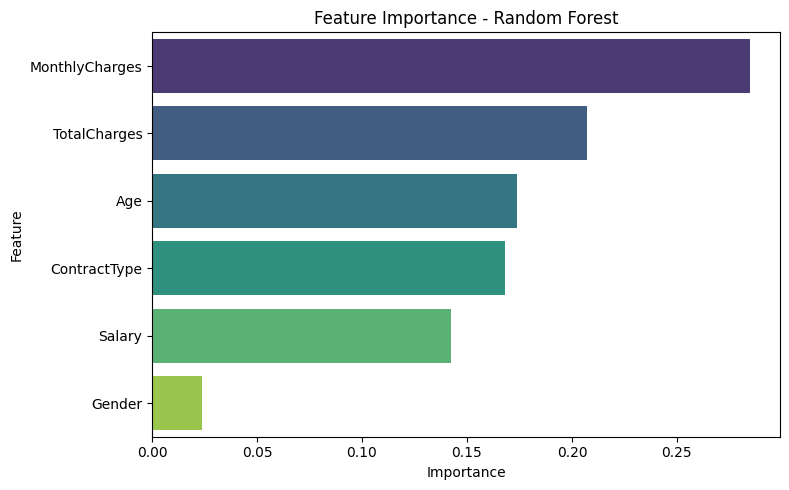


Fairness Summary by Gender
   Gender  total_samples  actual_positive_rate  predicted_positive_rate
0  Female             31              0.322581                 0.419355
1    Male             29              0.344828                 0.241379
Accuracy for Female: 0.7742
Accuracy for Male: 0.6207


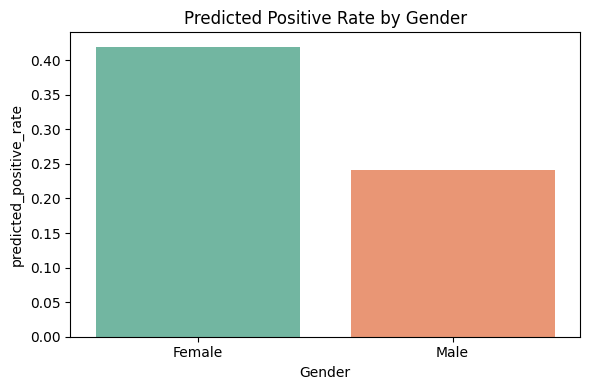

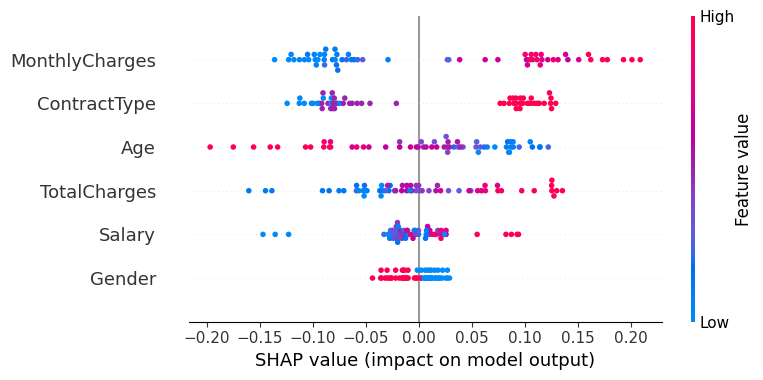

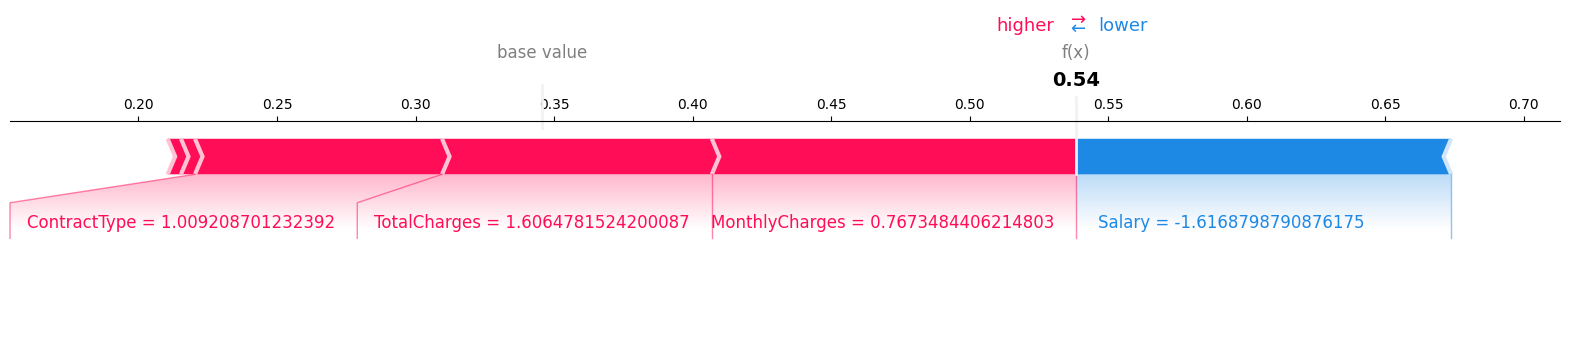


Mitigation Recommendations
1. Monitor prediction rates across gender regularly.
2. Re-evaluate use of Gender feature if disparity is high.
3. Adjust decision thresholds for fairness if needed.
4. Collect more balanced data across groups.
5. Use SHAP and fairness checks before deployment.


In [2]:
# Task 3: Fairness, Bias and Explainability Analysis (Google Colab)
!pip -q install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)

rows = []
for i in range(297):
    customer_id = i + 1
    gender = np.random.choice(['Male', 'Female'])
    age = np.random.randint(22, 66)
    salary = np.random.randint(35000, 95001)
    contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], p=[0.45, 0.30, 0.25])

    if contract == 'Month-to-month':
        monthly = np.random.randint(140, 181)
        churn_prob = 0.55
    elif contract == 'One year':
        monthly = np.random.randint(95, 116)
        churn_prob = 0.20
    else:
        monthly = np.random.randint(88, 106)
        churn_prob = 0.10

    tenure_months = np.random.randint(6, 37)
    total = monthly * tenure_months

    if age < 30:
        churn_prob += 0.15
    elif age > 50:
        churn_prob -= 0.10

    churn = 'Yes' if np.random.rand() < churn_prob else 'No'
    rows.append([customer_id, gender, age, salary, contract, monthly, total, churn])

df = pd.DataFrame(rows, columns=['CustomerID', 'Gender', 'Age', 'Salary', 'ContractType', 'MonthlyCharges', 'TotalCharges', 'Churn'])
print('Dataset shape:', df.shape)

work = df.copy()
work['Gender_label'] = work['Gender']
work['Gender'] = work['Gender'].map({'Male': 1, 'Female': 0})
work['ContractType'] = work['ContractType'].map({'Month-to-month': 2, 'One year': 1, 'Two year': 0})
work['Churn'] = work['Churn'].map({'Yes': 1, 'No': 0})
work = work.drop('CustomerID', axis=1)

X = work.drop(['Churn', 'Gender_label'], axis=1)
y = work['Churn']
groups = work['Gender_label']

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)
proba = model.predict_proba(X_test_scaled)[:, 1]

print('\nOverall Metrics')
print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print('Precision:', round(precision_score(y_test, pred), 4))
print('Recall:', round(recall_score(y_test, pred), 4))
print('F1 Score:', round(f1_score(y_test, pred), 4))

fi = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
print('\nFeature Importance')
print(fi)

plt.figure(figsize=(8, 5))
sns.barplot(data=fi, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

results = pd.DataFrame({'Gender': g_test.values, 'Actual': y_test.values, 'Predicted': pred, 'Probability': proba})
summary = results.groupby('Gender').agg(
    total_samples=('Actual', 'count'),
    actual_positive_rate=('Actual', 'mean'),
    predicted_positive_rate=('Predicted', 'mean')
).reset_index()

print('\nFairness Summary by Gender')
print(summary)

for gender in results['Gender'].unique():
    subset = results[results['Gender'] == gender]
    print(f"Accuracy for {gender}:", round(accuracy_score(subset['Actual'], subset['Predicted']), 4))

plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x='Gender', y='predicted_positive_rate', palette='Set2')
plt.title('Predicted Positive Rate by Gender')
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    sv = shap_values

if sv.ndim == 3:
    sv = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]

if sv.shape[1] != X_test_scaled.shape[1]:
    sv = sv.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1])

shap.summary_plot(sv, X_test_scaled, feature_names=X.columns)
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    sv[0],
    X_test_scaled[0],
    feature_names=X.columns,
    matplotlib=True
)
plt.show()

print('\nMitigation Recommendations')
print('1. Monitor prediction rates across gender regularly.')
print('2. Re-evaluate use of Gender feature if disparity is high.')
print('3. Adjust decision thresholds for fairness if needed.')
print('4. Collect more balanced data across groups.')
print('5. Use SHAP and fairness checks before deployment.')